# Categorizing Trends in Science: Clustering arXiv Papers (2020 – June 2026)

Case study for the course *Machine Learning – Unsupervised Learning and Feature Engineering* (DLBDSMLUSL01), Task 3.

**Goal:** a quantitative overview of current research topics, obtained by clustering paper titles and abstracts into homogeneous groups, visualising them in low-dimensional views, and analysing how the topics develop over time.

**Pipeline**
1. Exploratory data analysis
2. Filtering and text preprocessing
3. Feature engineering (TF-IDF, uni- and bigrams)
4. Dimensionality reduction (Truncated SVD / LSA; UMAP for visualisation)
5. Clustering (K-Means, choice of k, stability check)
6. Topic overview, trends over time, comparison with arXiv categories
7. Correction of sampling bias (post-stratification) and robust trends

**Data:** [arXiv Scientific Research Papers Dataset (Kaggle)](https://www.kaggle.com/datasets/sumitm004/arxiv-scientific-research-papers-dataset). Download the CSV and place it next to this notebook (see `DATA_PATH`).

**Runtime:** about 45–60 minutes on a standard Google Colab CPU runtime (the k-selection loop in Section 5.1 is the slowest step).

## 0. Setup

In [1]:
# Only needed on Google Colab; locally use: pip install -r requirements.txt
!pip install -q umap-learn

In [2]:
import os
import re
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import nltk
import umap
from nltk.stem import WordNetLemmatizer
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score)

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# ---------------- Settings ----------------
DATA_PATH  = "arXiv_scientific dataset.csv"   # raw Kaggle CSV
FIG_DIR, OUT_DIR = "figures", "data"
SEED       = 42
START_YEAR = 2020        # "current" research: 2020 - June 2026
MIN_WORDS  = 20          # minimum abstract length
N_SVD_FIT  = 300         # SVD components computed (variance analysis)
N_SVD_KEEP = 100         # SVD components used for clustering
SAMPLE_2D  = 60_000      # papers shown in 2D plots
K_RANGE    = [5, 8, 10, 12, 15, 18, 20, 25, 30, 35, 40]
K_COMPARE  = 20          # first choice from the metrics
K_FINAL    = 25          # final choice after inspection + stability check

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 120

def savefig(name):
    """Tidy layout, save to figures/<name>.png and display."""
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", bbox_inches="tight")
    plt.show()

def norm_text(s):
    """Lower-case and collapse whitespace (used for duplicate detection)."""
    return s.str.lower().str.replace(r"\s+", " ", regex=True).str.strip()

## 1. Exploratory Data Analysis
Data quality, time span, category balance and properties of the raw text.

In [3]:
raw = pd.read_csv(DATA_PATH)
print(raw.shape)
raw.info()

print("\nDuplicate ids:      ", raw["id"].duplicated().sum())
print("Duplicate titles:   ", norm_text(raw["title"]).duplicated().sum())
print("Duplicate abstracts:", norm_text(raw["summary"]).duplicated().sum())
print(f"Abstracts < {MIN_WORDS} words:", (raw["summary_word_count"] < MIN_WORDS).sum())

(287421, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287421 entries, 0 to 287420
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   id                  287421 non-null  object
 1   title               287421 non-null  object
 2   category            287421 non-null  object
 3   category_code       287421 non-null  object
 4   published_date      287421 non-null  object
 5   updated_date        287421 non-null  object
 6   authors             287421 non-null  object
 7   first_author        287421 non-null  object
 8   summary             287421 non-null  object
 9   summary_word_count  287421 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 21.9+ MB

Duplicate ids:       0
Duplicate titles:    134
Duplicate abstracts: 75
Abstracts < 20 words: 112


Range: 1993-08-01 to 2026-06-18
year
1993        6
1994      175
1995      251
1996      229
1997      182
1998       66
1999       74
2000      210
2001      106
2002      151
2003      148
2004      129
2005      134
2006      205
2007      263
2008      447
2009      616
2010      749
2011     1150
2012     2116
2013     2764
2014     2799
2015     3668
2016     6447
2017     9618
2018    12373
2019    14846
2020    16124
2021    15618
2022    16210
2023    15264
2024    12575
2025    93801
2026    57907


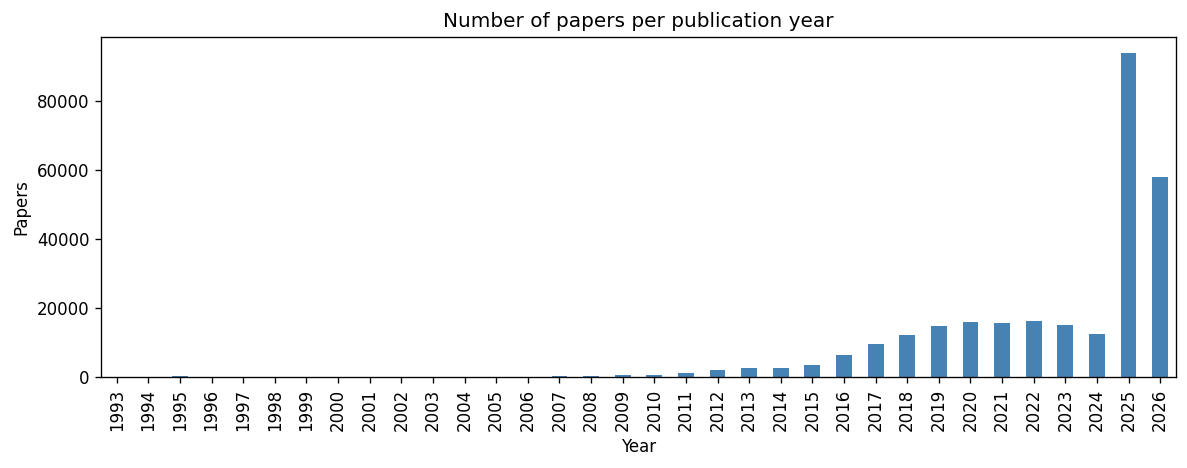

In [4]:
# 1.2 Time span
raw["published_date"] = pd.to_datetime(raw["published_date"], format="%m/%d/%y")
raw["year"] = raw["published_date"].dt.year
print("Range:", raw["published_date"].min().date(), "to", raw["published_date"].max().date())
per_year = raw["year"].value_counts().sort_index()
print(per_year.to_string())

ax = per_year.plot(kind="bar", figsize=(10, 4), color="steelblue")
ax.set(title="Number of papers per publication year", xlabel="Year", ylabel="Papers")
savefig("fig_papers_per_year")

Unique category codes: 147
main_field
cs          254609
stat         16393
eess          5425
math          3031
q-bio         1980
physics       1711
quant-ph      1052
cmp-lg         750
cond-mat       714
q-fin          570
Top 10 categories cover 88.1% of all papers


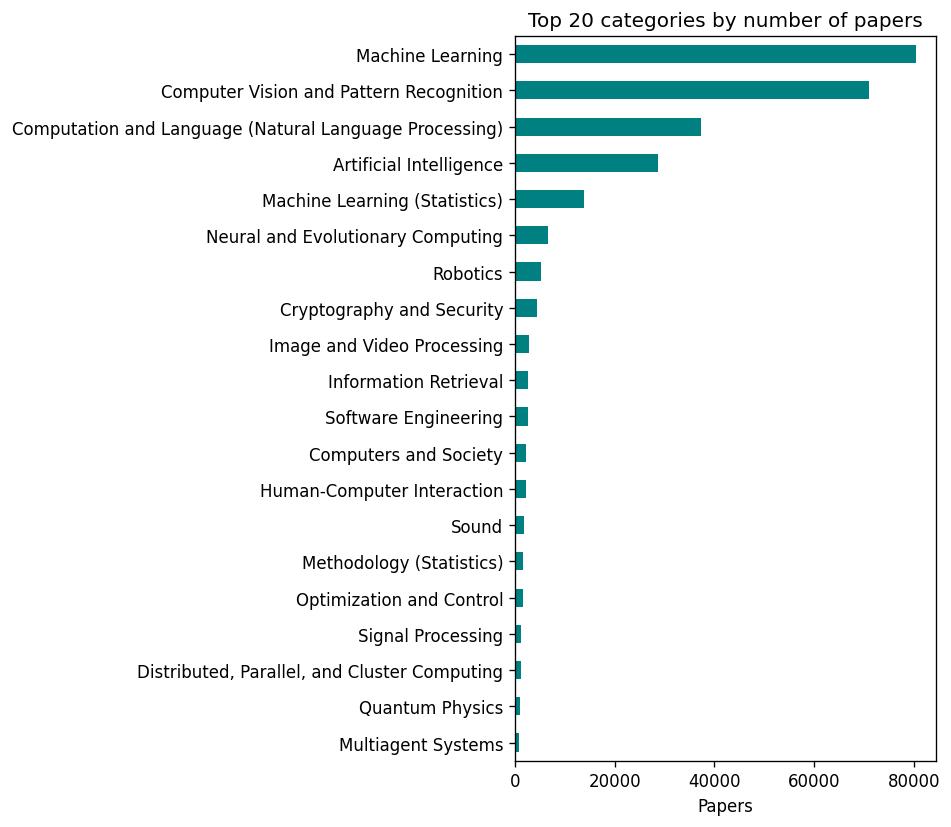

In [5]:
# 1.3 Categories
print("Unique category codes:", raw["category_code"].nunique())
raw["main_field"] = raw["category_code"].str.split(".").str[0]
print(raw["main_field"].value_counts().head(10).to_string())
share_top10 = raw["category"].value_counts().head(10).sum() / len(raw)
print(f"Top 10 categories cover {share_top10:.1%} of all papers")

ax = raw["category"].value_counts().head(20).sort_values().plot(kind="barh", figsize=(8, 7), color="teal")
ax.set(title="Top 20 categories by number of papers", xlabel="Papers", ylabel="")
savefig("fig_top20_categories")

       summary_word_count  title_word_count
count            287421.0          287421.0
mean                171.0               9.6
std                  45.9               3.1
min                   1.0               1.0
25%                 140.0               7.0
50%                 170.0               9.0
75%                 202.0              11.0
max                 552.0              36.0


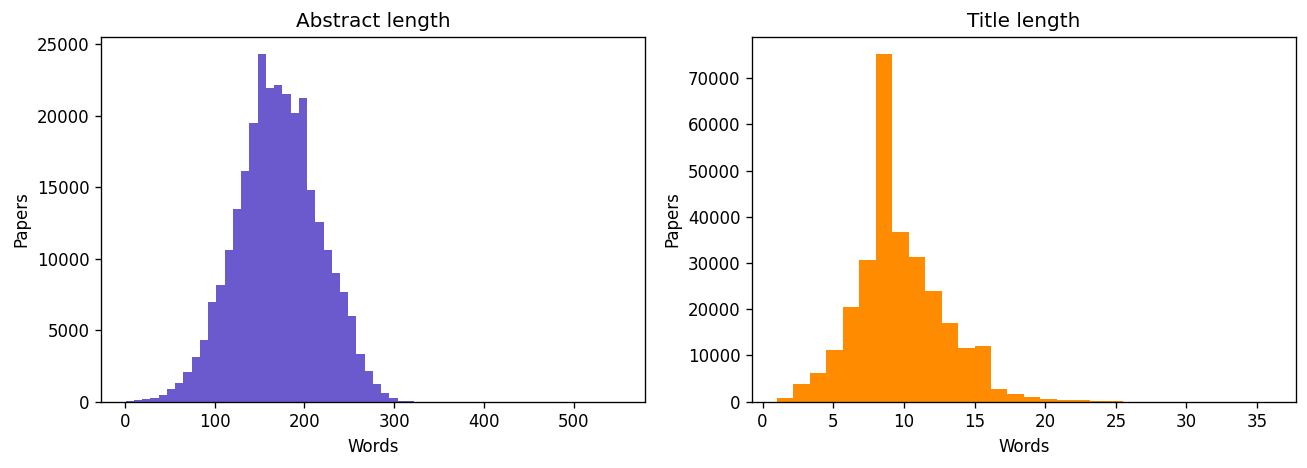

Abstracts containing LaTeX '$': 26047
Abstracts containing URLs:      32967


In [6]:
# 1.4 Text length and noise in the raw text
raw["title_word_count"] = raw["title"].str.split().str.len()
print(raw[["summary_word_count", "title_word_count"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
raw["summary_word_count"].plot(kind="hist", bins=60, ax=axes[0], color="slateblue")
axes[0].set(title="Abstract length", xlabel="Words", ylabel="Papers")
raw["title_word_count"].plot(kind="hist", bins=30, ax=axes[1], color="darkorange")
axes[1].set(title="Title length", xlabel="Words", ylabel="Papers")
savefig("fig_text_lengths")

print("Abstracts containing LaTeX '$':", raw["summary"].str.contains(r"\$", regex=True).sum())
print("Abstracts containing URLs:     ", raw["summary"].str.contains(r"(?i)http", regex=True).sum())

## 2. Filtering and Text Preprocessing
Restrict to recent papers, remove duplicates and near-empty abstracts, then clean the text
(URLs, LaTeX, punctuation, stopwords incl. academic boilerplate, lemmatisation).

In [7]:
# 2.1 Filtering (the log becomes a table in the report)
df = raw[raw["year"] >= START_YEAR]
log = [("Raw dataset", len(raw)), (f"Published {START_YEAR} or later", len(df))]
df = df[~norm_text(df["summary"]).duplicated()];  log.append(("Duplicate abstracts removed", len(df)))
df = df[~norm_text(df["title"]).duplicated()];    log.append(("Duplicate titles removed", len(df)))
df = df[df["summary_word_count"] >= MIN_WORDS].reset_index(drop=True)
log.append((f"Abstracts < {MIN_WORDS} words removed", len(df)))

log_df = pd.DataFrame(log, columns=["Step", "Papers remaining"])
log_df.to_csv(f"{OUT_DIR}/filtering_log.csv", index=False)
print(log_df.to_string(index=False))

                        Step  Papers remaining
                 Raw dataset            287421
     Published 2020 or later            227499
 Duplicate abstracts removed            227460
    Duplicate titles removed            227419
Abstracts < 20 words removed            227389


In [10]:
# 2.2 Cleaning functions
def regex_clean(s: pd.Series) -> pd.Series:
    s = s.str.replace(r"(?i)http\S+|www\.\S+", " ", regex=True)          # URLs
    s = s.str.replace(r"\$\$.*?\$\$", " ", regex=True, flags=re.DOTALL)  # display math
    s = s.str.replace(r"\$.*?\$", " ", regex=True, flags=re.DOTALL)      # inline math
    s = s.str.replace(r"\\[a-zA-Z]+", " ", regex=True)                   # LaTeX commands
    s = s.str.lower()
    s = s.str.replace(r"[^a-z\s]", " ", regex=True)                      # digits, punctuation
    return s.str.replace(r"\s+", " ", regex=True).str.strip()

# Academic boilerplate that appears in almost every abstract and carries no topic
DOMAIN_STOP = {
    "paper", "propose", "proposed", "present", "presents", "approach", "method",
    "result", "show", "demonstrate", "based", "using", "use", "used", "novel",
    "new", "study", "work", "also", "furthermore", "moreover", "however",
    "significantly", "effectively", "existing", "experiment", "experimental",
    "state", "art", "outperforms", "introduce", "various", "different", "way",
    "achieve", "provide", "code", "available", "github", "extensive",
}
STOP = set(ENGLISH_STOP_WORDS) | DOMAIN_STOP

# WordNet shortens some words wrongly ("data" -> "datum") -> protect them
PROTECT = {"data", "physics", "dynamics", "robotics", "graphics", "statistics",
           "analysis", "bias", "gas", "lens", "mathematics", "economics",
           "linguistics", "genetics", "kinematics", "diagnosis", "basis"}
# Modern plurals WordNet does not know
FIX = {"datasets": "dataset", "llms": "llm", "benchmarks": "benchmark"}

lemmatizer = WordNetLemmatizer()

@lru_cache(maxsize=None)
def lemma(word: str) -> str:
    return FIX.get(word) or (word if word in PROTECT else lemmatizer.lemmatize(word))

def tokens_clean(text: str) -> str:
    out = []
    for w in text.split():
        if w in STOP:
            continue
        w = lemma(w)
        if len(w) >= 2 and w not in STOP:
            out.append(w)
    return " ".join(out)

Remaining '$': 0
count    227389.0
mean        115.4
std          29.5
min           9.0
25%          95.0
50%         115.0
75%         136.0
max         335.0
Name: n_tokens, dtype: float64

BEFORE: Relative Bias: A Comparative Framework for Quantifying Bias in LLMs. The growing deployment of large language models (LLMs) has amplified concerns regarding their inherent biases, raising critical questions about their fairness, safety, and societal impact. However, quantifying LLM bias remains a fu
AFTER : relative bias comparative framework quantifying bias llm growing deployment large language model llm amplified concern regarding inherent bias raising critical question fairness safety societal impact quantifying llm bias remains fundamental challenge complicated ambiguity bias entail challenge grow

BEFORE: Customizing a Large Language Model for VHDL Design of High-Performance Microprocessors. The use of Large Language Models (LLMs) in hardware design has taken off in recent years, pr

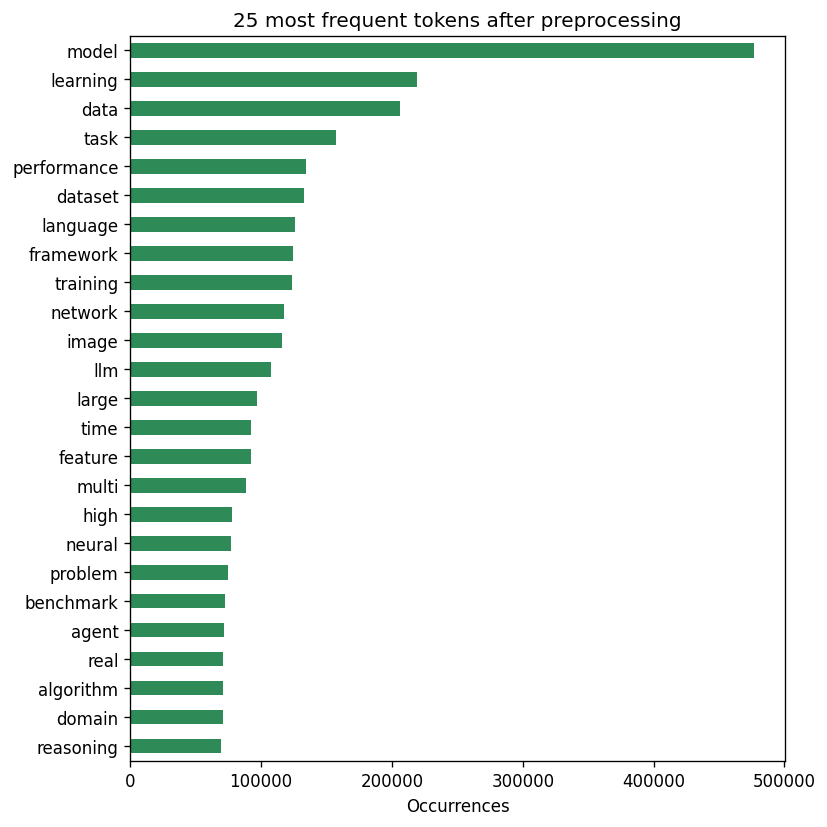

Papers per year after filtering:
 year
2020    16115
2021    15604
2022    16203
2023    15257
2024    12571
2025    93752
2026    57887


In [11]:
# 2.3 Apply cleaning (title + abstract), check result, save
df["text_raw"] = df["title"].str.strip() + ". " + df["summary"].str.strip()
df["text_clean"] = regex_clean(df["text_raw"]).apply(tokens_clean)
df["n_tokens"] = df["text_clean"].str.split().str.len()

print("Remaining '$':", df["text_clean"].str.contains(r"\$", regex=True).sum())
print(df["n_tokens"].describe().round(1))
for i in df.sample(2, random_state=1).index:
    print("\nBEFORE:", df.at[i, "text_raw"][:300])
    print("AFTER :", df.at[i, "text_clean"][:300])

word_freq = df["text_clean"].str.split().explode().value_counts()
ax = word_freq.head(25).sort_values().plot(kind="barh", figsize=(7, 7), color="seagreen")
ax.set(title="25 most frequent tokens after preprocessing", xlabel="Occurrences", ylabel="")
savefig("fig_top_tokens")

df.drop(columns=["summary", "authors"], errors="ignore").to_parquet(f"{OUT_DIR}/papers_clean.parquet", index=False)
print("Papers per year after filtering:\n", df["year"].value_counts().sort_index().to_string())

## 3. Feature Engineering: TF-IDF
Document frequencies justify `max_df`; uni- and bigrams capture phrases such as "language model".

text_clean
model          71.4
learning       43.2
performance    40.4
data           40.0
framework      36.2
task           35.3
dataset        34.8
large          30.9
training       29.6
language       28.3
high           24.4
network        23.9
benchmark      22.8
time           22.7
address        22.6


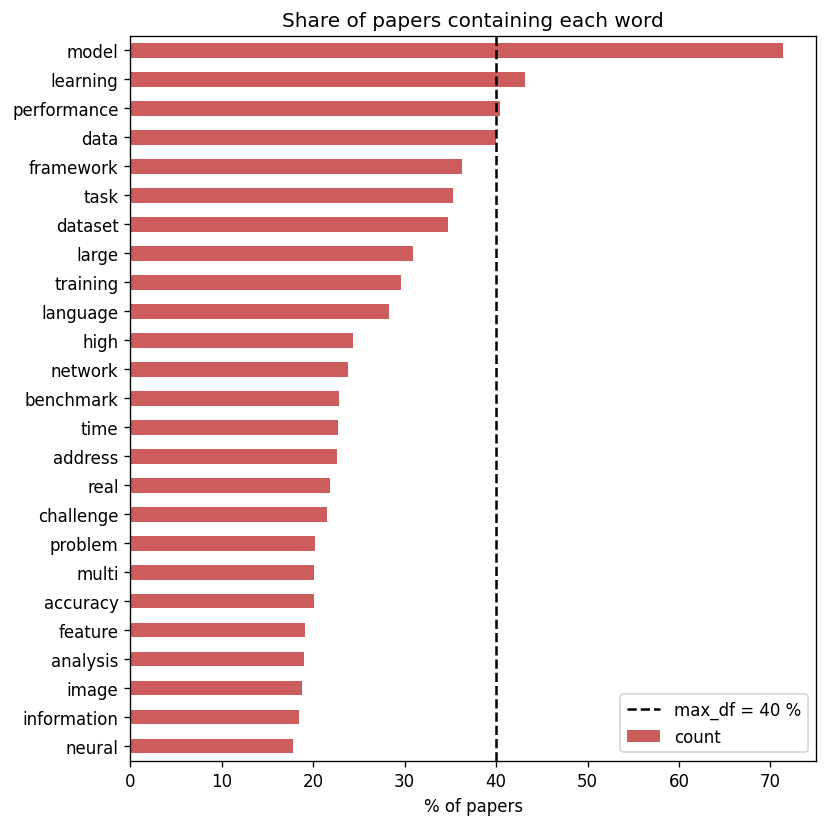

In [12]:
# 3.1 Share of papers containing each word -> evidence for max_df
doc_freq = df["text_clean"].str.split().apply(set).explode().value_counts() / len(df)
print((doc_freq.head(15) * 100).round(1).to_string())

ax = (doc_freq.head(25) * 100).sort_values().plot(kind="barh", figsize=(7, 7), color="indianred")
ax.axvline(40, ls="--", color="black", label="max_df = 40 %")
ax.set(title="Share of papers containing each word", xlabel="% of papers", ylabel="")
ax.legend()
savefig("fig_document_frequency")

In [13]:
# 3.2 TF-IDF matrix
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=20, max_df=0.40,
                             max_features=50_000, sublinear_tf=True, dtype=np.float32)
X = vectorizer.fit_transform(df["text_clean"])
terms = np.array(vectorizer.get_feature_names_out())

print("Matrix shape:", X.shape, f"| density: {X.nnz / np.prod(X.shape):.4%}")
print("Bigrams in vocabulary:", sum(" " in t for t in terms))
print("Removed as too generic:", [w for w in doc_freq.index[:40] if w not in vectorizer.vocabulary_])

for i in df.sample(3, random_state=7).index:                      # sanity check
    top = terms[X[i].toarray().ravel().argsort()[::-1][:8]]
    print(f"\n{df.at[i, 'title'][:90]}\n   top terms: {', '.join(top)}")

sparse.save_npz(f"{OUT_DIR}/tfidf_matrix.npz", X)
joblib.dump(vectorizer, f"{OUT_DIR}/tfidf_vectorizer.joblib")

Matrix shape: (227389, 50000) | density: 0.2137%
Bigrams in vocabulary: 37510
Removed as too generic: ['model', 'learning', 'performance']

ActionSink: Toward Precise Robot Manipulation with Dynamic Integration of Action Flow
   top terms: robot manipulation, action, working memory, libero, flow, manipulation, robot, estimation

Profiling Obese Subgroups in National Health and Nutritional Status
  Survey Data using Ma
   top terms: nutritional, subgroup, status, health, national, principal component, principal, obesity

Facts Do Care About Your Language: Assessing Answer Quality of Multilingual LLMs
   top terms: school student, factual question, llama family, correctness, extraneous, continues grow, high school, untested


['data/tfidf_vectorizer.joblib']

## 4. Dimensionality Reduction
**Truncated SVD (LSA)** compresses 50,000 sparse TF-IDF dimensions to 100 dense ones (input for clustering).
**UMAP** projects these to 2D for visualisation only.

 10 components -> 2.1% of variance
 50 components -> 5.9% of variance
100 components -> 8.7% of variance
150 components -> 11.0% of variance
200 components -> 12.8% of variance
300 components -> 15.9% of variance


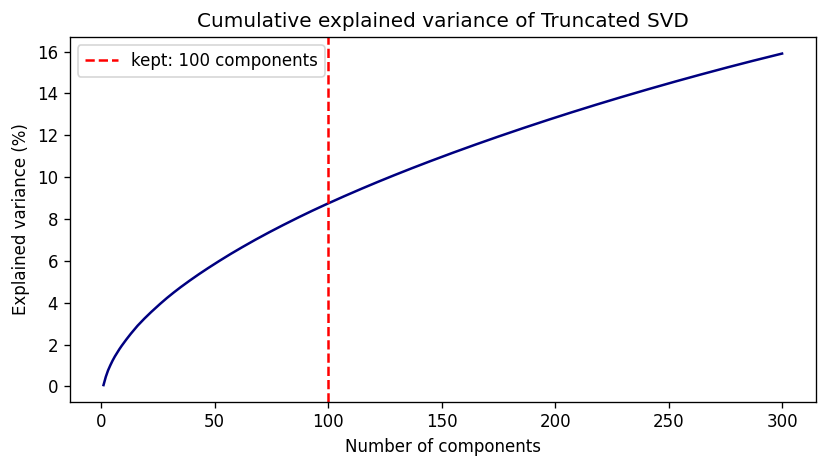

Component 0: data, task, language, dataset, training, framework, llm, network, large, image
Component 1: llm, language, language model, reasoning, large language, large, model llm, agent, text, generation
Component 2: image, object, video, feature, visual, segmentation, scene, representation, semantic, dataset
Component 3: policy, reinforcement, reinforcement learning, rl, reward, diffusion, agent, action, video, optimization
Component 4: ai, agent, real, world, human, environment, detection, real world, research, decision
Component 5: network, neural, neural network, graph, memory, architecture, agent, reasoning, layer, attention
Component 6: graph, reinforcement, reinforcement learning, task, policy, rl, representation, agent, supervised, node
Component 7: graph, generation, diffusion, structure, generative, latent, text, space, diffusion model, representation
Component 8: neural, image, neural network, network, deep, human, reinforcement, reinforcement learning, ai, text
Component 9

In [14]:
# 4.1 Truncated SVD and explained variance
svd = TruncatedSVD(n_components=N_SVD_FIT, algorithm="randomized", n_iter=5, random_state=SEED)
Z_full = svd.fit_transform(X)
cum = np.cumsum(svd.explained_variance_ratio_)
for k in [10, 50, 100, 150, 200, 300]:
    print(f"{k:>3} components -> {cum[k-1]:.1%} of variance")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, N_SVD_FIT + 1), cum * 100, color="navy")
ax.axvline(N_SVD_KEEP, ls="--", color="red", label=f"kept: {N_SVD_KEEP} components")
ax.set(title="Cumulative explained variance of Truncated SVD",
       xlabel="Number of components", ylabel="Explained variance (%)")
ax.legend()
savefig("fig_svd_variance")

for c in range(10):                                                 # interpretability
    print(f"Component {c}: {', '.join(terms[svd.components_[c].argsort()[::-1][:10]])}")

# 4.2 Keep N_SVD_KEEP components, L2-normalise (Euclidean ~ cosine)
Z = normalize(Z_full[:, :N_SVD_KEEP]).astype(np.float32)
np.save(f"{OUT_DIR}/svd_reduced.npy", Z)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


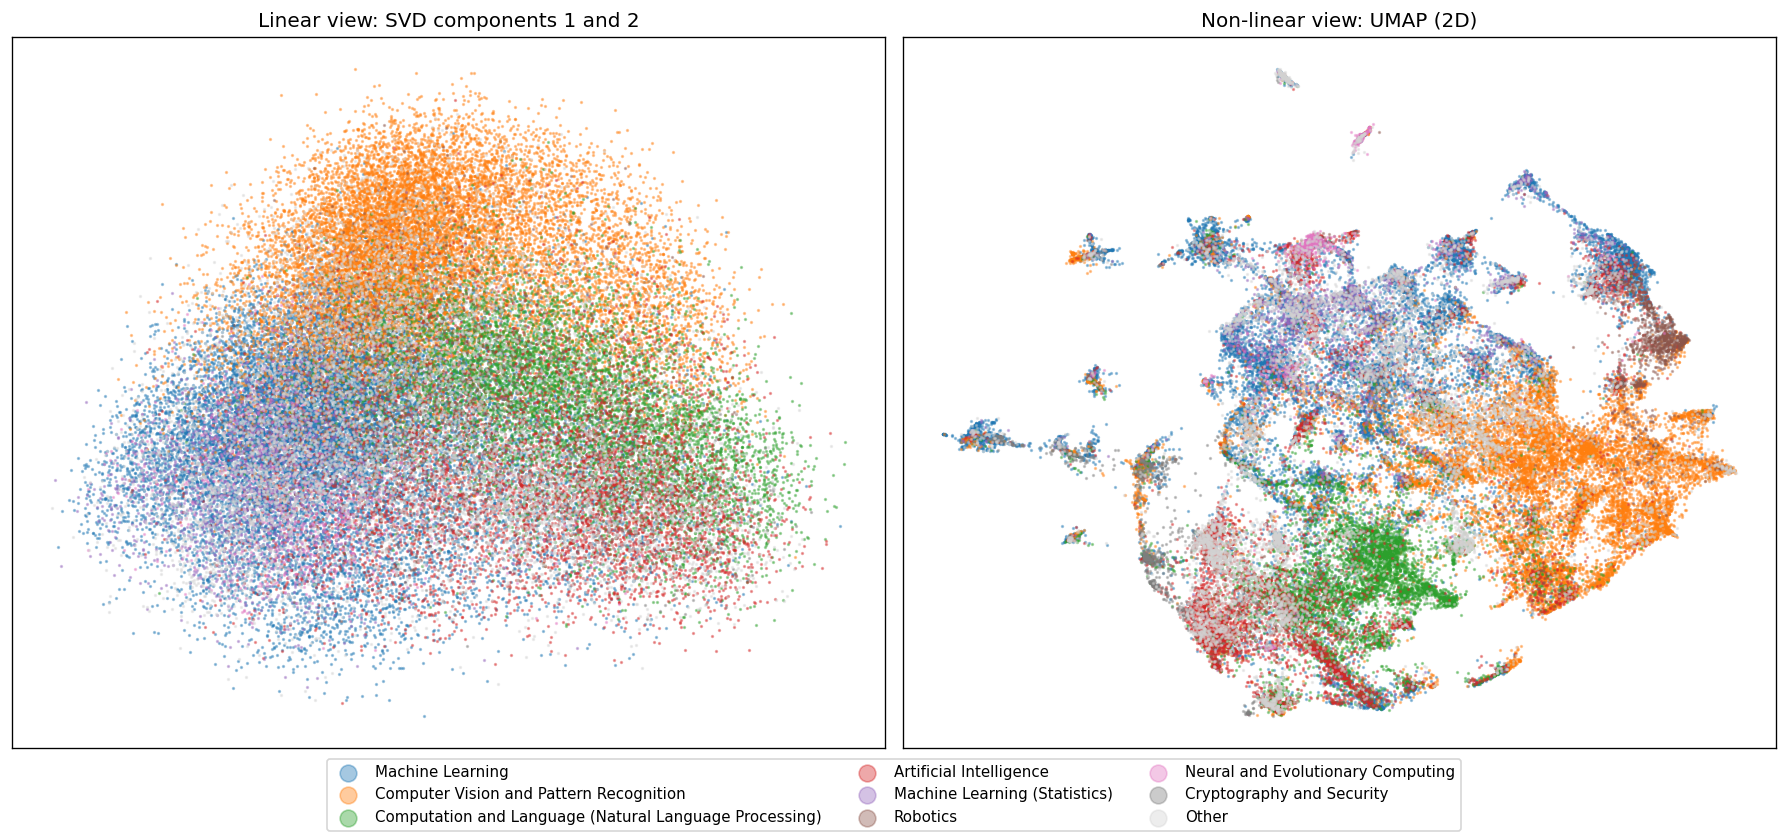

In [15]:
# 4.3 2D views on a random sample: linear (SVD) vs non-linear (UMAP)
rng = np.random.default_rng(SEED)
idx = np.sort(rng.choice(len(df), SAMPLE_2D, replace=False))
emb = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED).fit_transform(Z[idx])
np.save(f"{OUT_DIR}/umap_2d.npy", emb); np.save(f"{OUT_DIR}/umap_idx.npy", idx)

top_cats = df["category"].value_counts().head(8).index
cat_s = df["category"].where(df["category"].isin(top_cats), "Other").iloc[idx].values

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, coords, title in [(axes[0], Z[idx][:, 1:3], "Linear view: SVD components 1 and 2"),
                          (axes[1], emb, "Non-linear view: UMAP (2D)")]:
    for cat in list(top_cats) + ["Other"]:
        m = cat_s == cat
        ax.scatter(coords[m, 0], coords[m, 1], s=1, alpha=0.4, label=cat,
                   color="lightgrey" if cat == "Other" else None)
    ax.set(title=title, xticks=[], yticks=[])
handles, labels_ = axes[1].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=3, markerscale=10, fontsize=9)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(f"{FIG_DIR}/fig_2d_views.png", bbox_inches="tight"); plt.show()

## 5. Clustering with K-Means
5.1 internal validity indices for a range of k · 5.2 final models for k = 20 and k = 25 and their stability ·
5.3 cluster description (top terms, example titles, UMAP view).

k=5 done
k=8 done
k=10 done
k=12 done
k=15 done
k=18 done
k=20 done
k=25 done
k=30 done
k=35 done
k=40 done
 k     inertia  silhouette  davies_bouldin  calinski_harabasz  smallest_cluster_%
 5 171065.9219      0.0369          4.3984        5446.802734              6.8640
 8 164718.2500      0.0382          4.2752        4484.126953              6.1335
10 161074.3750      0.0439          3.9306        4137.830566              4.3309
12 157776.1562      0.0497          3.7175        3888.669922              1.5449
15 154306.2500      0.0506          3.6102        3489.036865              3.2236
18 150931.3281      0.0523          3.5590        3236.928955              1.5014
20 148450.8125      0.0572          3.2838        3144.127930              1.4886
25 144370.3594      0.0602          3.1251        2827.262451              1.4653
30 139992.0469      0.0659          3.0337        2658.261963              1.4526
35 136447.8594      0.0695          2.9510        2499.816162           

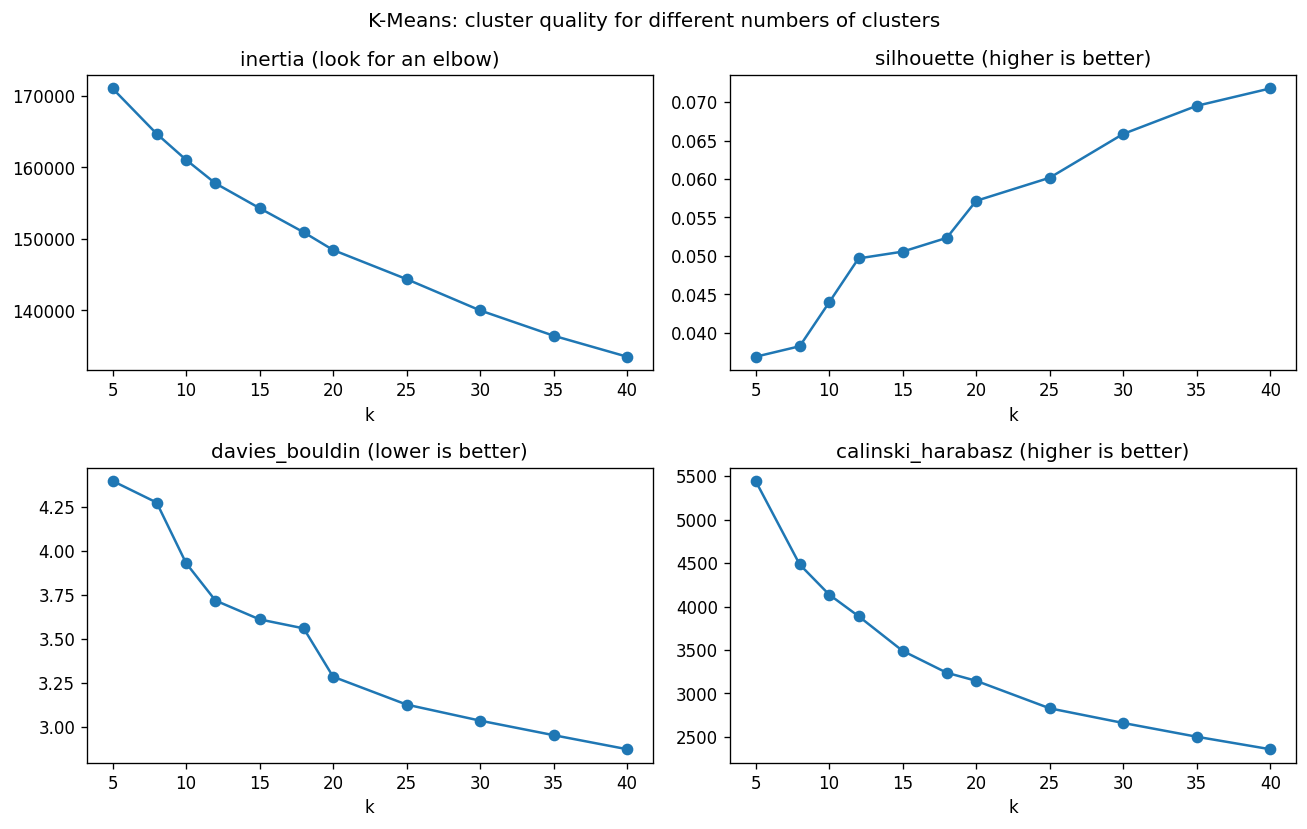

In [16]:
# 5.1 Choosing k (silhouette on a 20k sample, as it is O(n^2))
sil_idx = np.random.default_rng(SEED).choice(len(Z), 20_000, replace=False)
rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=3, random_state=SEED).fit(Z)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(Z[sil_idx], km.labels_[sil_idx]),
                 "davies_bouldin": davies_bouldin_score(Z, km.labels_),
                 "calinski_harabasz": calinski_harabasz_score(Z, km.labels_),
                 "smallest_cluster_%": np.bincount(km.labels_).min() / len(Z) * 100})
    print(f"k={k} done")
metrics = pd.DataFrame(rows)
metrics.to_csv(f"{OUT_DIR}/kmeans_k_selection.csv", index=False)
print(metrics.round(4).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col, note in zip(axes.ravel(), ["inertia", "silhouette", "davies_bouldin", "calinski_harabasz"],
                         ["look for an elbow", "higher is better", "lower is better", "higher is better"]):
    ax.plot(metrics["k"], metrics[col], marker="o")
    ax.set(title=f"{col} ({note})", xlabel="k")
plt.suptitle("K-Means: cluster quality for different numbers of clusters")
savefig("fig_k_selection")

In [17]:
# 5.2 Final models (10 restarts) for k = 20 and k = 25, and their stability
labels_by_k = {}
for k in [K_COMPARE, K_FINAL]:
    labels_by_k[k] = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Z).labels_
    np.save(f"{OUT_DIR}/cluster_labels_k{k}.npy", labels_by_k[k])

l_a, l_b = labels_by_k[K_COMPARE], labels_by_k[K_FINAL]
print(f"Adjusted Rand Index (k={K_COMPARE} vs k={K_FINAL}): {adjusted_rand_score(l_a, l_b):.3f}")
ct = pd.crosstab(l_a, l_b, normalize="index")
for c in range(K_COMPARE):
    main = ct.loc[c][ct.loc[c] > 0.2]
    print(f"k{K_COMPARE} cluster {c:>2} -> k{K_FINAL} clusters", {k: round(float(v), 2) for k, v in main.items()})

Adjusted Rand Index (k=20 vs k=25): 0.656
k20 cluster  0 -> k25 clusters {17: 0.94}
k20 cluster  1 -> k25 clusters {7: 0.72}
k20 cluster  2 -> k25 clusters {5: 0.83}
k20 cluster  3 -> k25 clusters {8: 0.4, 10: 0.55}
k20 cluster  4 -> k25 clusters {18: 0.7}
k20 cluster  5 -> k25 clusters {2: 0.94}
k20 cluster  6 -> k25 clusters {12: 0.9}
k20 cluster  7 -> k25 clusters {3: 0.72}
k20 cluster  8 -> k25 clusters {1: 0.96}
k20 cluster  9 -> k25 clusters {15: 0.79}
k20 cluster 10 -> k25 clusters {22: 0.79}
k20 cluster 11 -> k25 clusters {19: 0.93}
k20 cluster 12 -> k25 clusters {4: 0.63, 23: 0.22}
k20 cluster 13 -> k25 clusters {0: 0.95}
k20 cluster 14 -> k25 clusters {21: 0.8}
k20 cluster 15 -> k25 clusters {24: 0.98}
k20 cluster 16 -> k25 clusters {14: 0.94}
k20 cluster 17 -> k25 clusters {9: 0.71}
k20 cluster 18 -> k25 clusters {16: 0.88}
k20 cluster 19 -> k25 clusters {8: 0.66}


In [18]:
# 5.3 Describe clusters: size, top terms (mean TF-IDF), example titles
def describe_clusters(labels, k, n_titles=3):
    sizes = np.bincount(labels, minlength=k)
    rows = []
    for c in range(k):
        mean_tfidf = np.asarray(X[labels == c].mean(axis=0)).ravel()
        top = ", ".join(terms[mean_tfidf.argsort()[::-1][:12]])
        rows.append({"cluster": c, "papers": sizes[c], "share_%": round(sizes[c] / len(labels) * 100, 1), "top_terms": top})
        print(f"\nCluster {c:>2} ({sizes[c]:>6} papers, {sizes[c]/len(labels):.1%}): {top}")
        for t in df["title"][labels == c].sample(n_titles, random_state=SEED):
            print("     -", t[:100].replace("\n", " "))
    out = pd.DataFrame(rows)
    out.to_csv(f"{OUT_DIR}/cluster_top_terms_k{k}.csv", index=False)
    return out

top_terms_final = describe_clusters(labels_by_k[K_FINAL], K_FINAL)


Cluster  0 ( 10266 papers, 4.5%): reinforcement, reinforcement learning, policy, rl, reward, agent, environment, learning rl, action, algorithm, control, task
     - Task-Centric Policy Optimization from Misaligned Motion Priors
     - S-GRPO: Unified Post-Training for Large Vision-Language Models
     - Bootstrapped model learning and error correction for planning with   uncertainty in model-based RL

Cluster  1 (  4823 papers, 2.1%): time series, series, time, forecasting, series forecasting, data, temporal, series data, multivariate, prediction, multivariate time, forecast
     - Non-negative DAG Learning from Time-Series Data
     - On Error Correction Neural Networks for Economic Forecasting
     - Generative Predictive Distributions for Time Series

Cluster  2 (  4752 papers, 2.1%): attack, adversarial, defense, adversarial attack, robustness, perturbation, vulnerability, security, adversarial example, backdoor, threat, jailbreak
     - From Seed to Harvest: Augmenting Human Cre

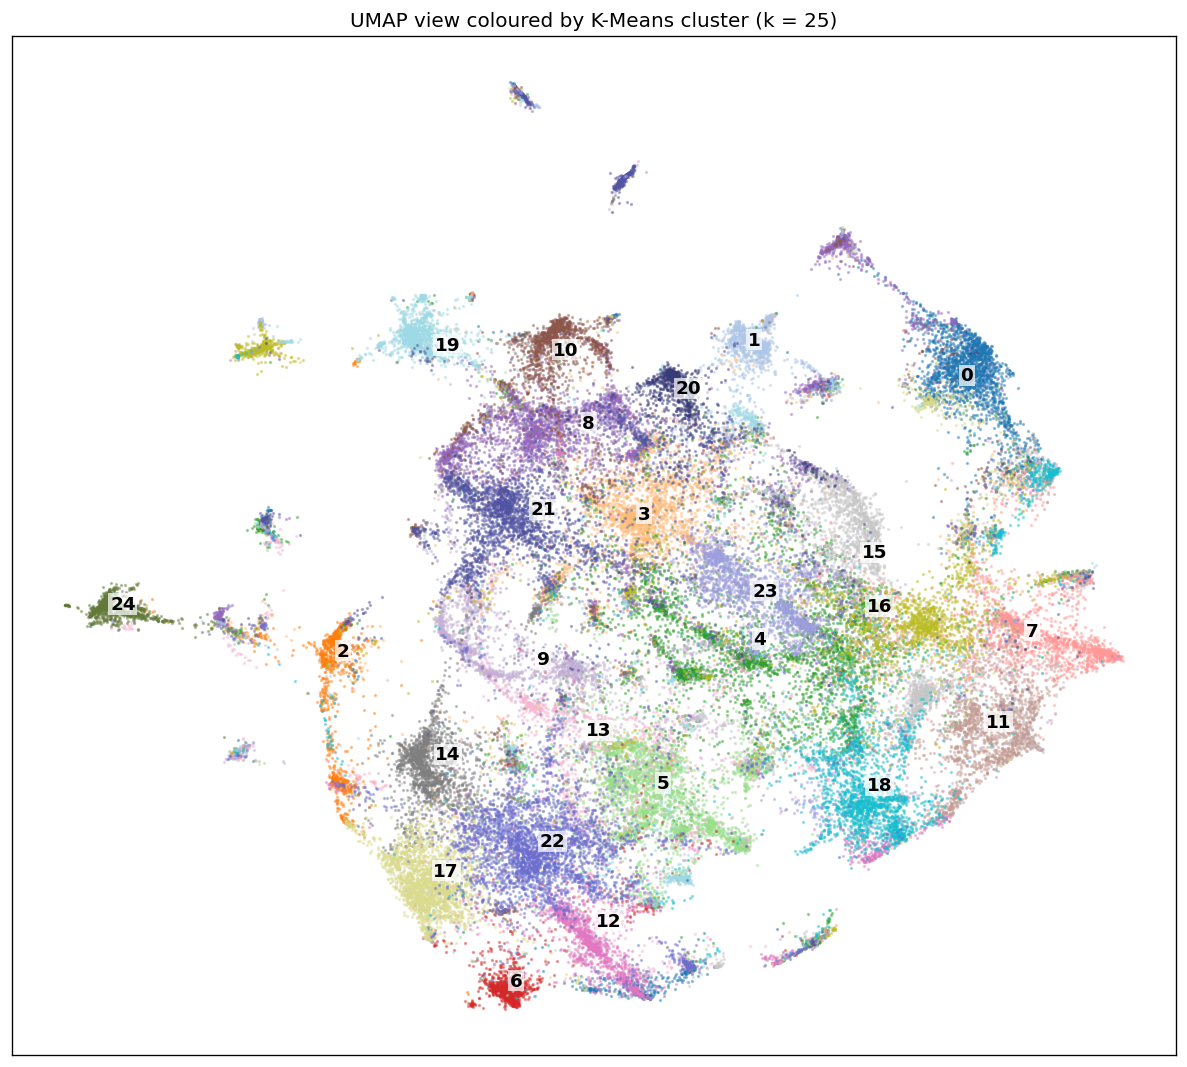

In [19]:
# UMAP view coloured by final cluster
lab_s = labels_by_k[K_FINAL][idx]
colors = np.vstack([plt.cm.tab20(np.arange(20)), plt.cm.tab20b(np.arange(20))])
fig, ax = plt.subplots(figsize=(10, 9))
for c in range(K_FINAL):
    m = lab_s == c
    ax.scatter(emb[m, 0], emb[m, 1], s=1, alpha=0.4, color=colors[c % 40])
    cx, cy = np.median(emb[m], axis=0)
    ax.text(cx, cy, str(c), fontsize=11, weight="bold",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1))
ax.set(title=f"UMAP view coloured by K-Means cluster (k = {K_FINAL})", xticks=[], yticks=[])
savefig(f"fig_umap_clusters_k{K_FINAL}")

## 6. Topic Overview, Trends and Comparison with arXiv Categories
Cluster names were assigned manually from the top terms and example titles.
**Check before continuing:** each name below must match the top terms printed in Section 5.3.

In [20]:
NAMES = {
    0: "Reinforcement learning & control",      1: "Time series forecasting",
    2: "Adversarial attacks & AI security",     3: "Applied machine learning (broad)",
    4: "Representation & supervised learning (broad)",
    5: "NLP, translation & speech",             6: "Retrieval-augmented generation (RAG)",
    7: "3D vision & scene reconstruction",      8: "Learning theory & statistical ML (broad)",
    9: "Efficient transformers & inference",    10: "Evolutionary & combinatorial optimization",
    11: "Video understanding & generation",     12: "LLM reasoning (chain-of-thought)",
    13: "LLM fine-tuning & PEFT",               14: "AI & society",
    15: "Diffusion & image generation",         16: "Object & anomaly detection",
    17: "LLM agents & multi-agent systems",     18: "Vision-language models",
    19: "Graph neural networks",                20: "Physics-informed ML",
    21: "Deep neural network architectures (broad)",
    22: "LLM evaluation & prompting",           23: "Medical & clinical AI",
    24: "Federated learning & privacy",
}
df["cluster"] = labels_by_k[K_FINAL]
df["topic"] = df["cluster"].map(NAMES)

# Quick check: name next to its top terms
for c in range(K_FINAL):
    print(f"{c:>2} {NAMES[c]:<46} | {top_terms_final.at[c, 'top_terms'][:70]}")

 0 Reinforcement learning & control               | reinforcement, reinforcement learning, policy, rl, reward, agent, envi
 1 Time series forecasting                        | time series, series, time, forecasting, series forecasting, data, temp
 2 Adversarial attacks & AI security              | attack, adversarial, defense, adversarial attack, robustness, perturba
 3 Applied machine learning (broad)               | machine, machine learning, data, prediction, ml, feature, dataset, lea
 4 Representation & supervised learning (broad)   | feature, image, data, representation, dataset, label, supervised, doma
 5 NLP, translation & speech                      | language, text, word, task, sentence, translation, dataset, english, n
 6 Retrieval-augmented generation (RAG)           | retrieval, rag, retrieval augmented, augmented, augmented generation, 
 7 3D vision & scene reconstruction               | scene, view, reconstruction, image, camera, pose, object, gaussian, es
 8 Learning theo

                                              papers  share_pct
topic                                                          
Representation & supervised learning (broad)   18661        8.2
Learning theory & statistical ML (broad)       16107        7.1
Deep neural network architectures (broad)      13677        6.0
LLM evaluation & prompting                     13575        6.0
NLP, translation & speech                      13139        5.8
Applied machine learning (broad)               12366        5.4
Reinforcement learning & control               10266        4.5
Vision-language models                          9914        4.4
LLM agents & multi-agent systems                9826        4.3
Efficient transformers & inference              9447        4.2
3D vision & scene reconstruction                9117        4.0
Diffusion & image generation                    9055        4.0
Object & anomaly detection                      8672        3.8
Graph neural networks                   

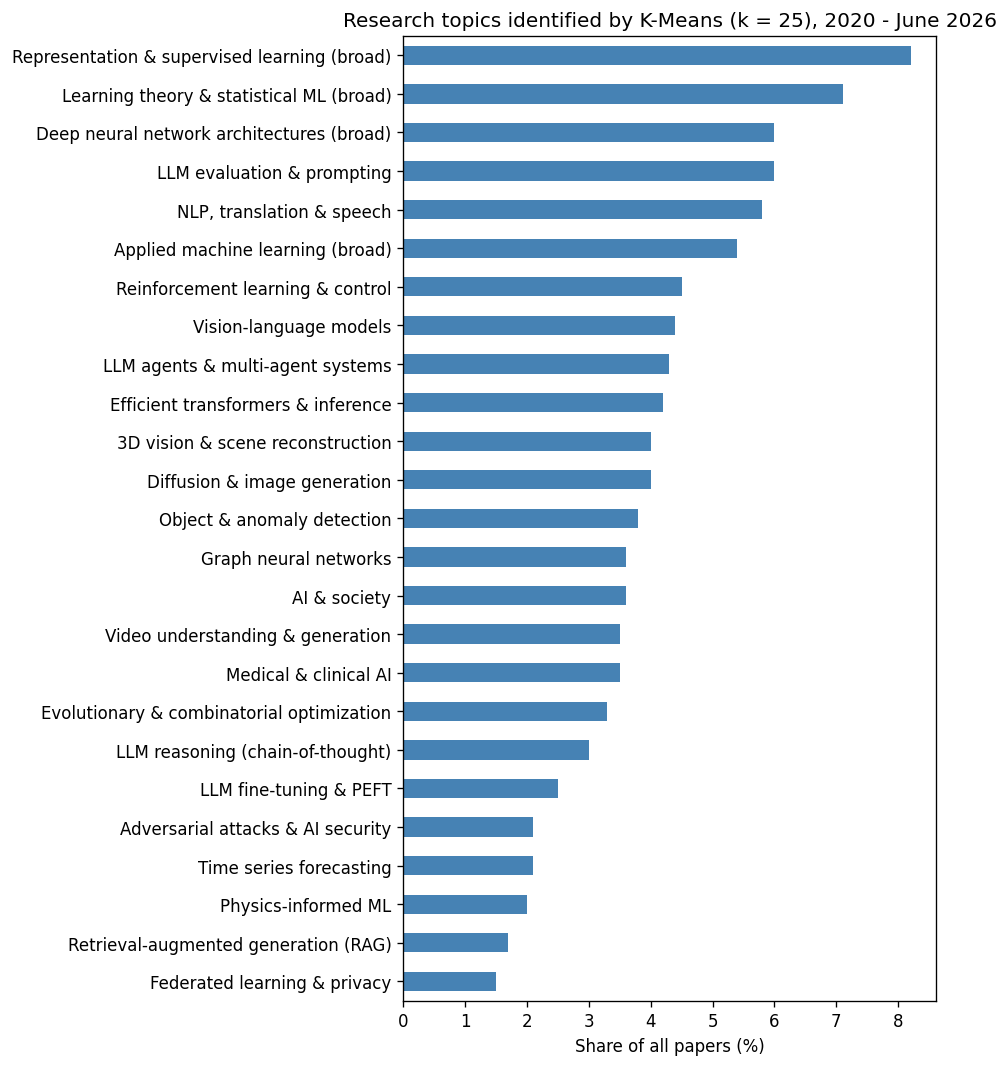

In [21]:
# 6.1 Overview of all topics
overview = (df["topic"].value_counts().rename("papers").to_frame()
            .assign(share_pct=lambda t: (t["papers"] / len(df) * 100).round(1)))
overview.to_csv(f"{OUT_DIR}/topic_overview.csv")
print(overview.to_string())

ax = overview["share_pct"].sort_values().plot(kind="barh", figsize=(8, 9), color="steelblue")
ax.set(title=f"Research topics identified by K-Means (k = {K_FINAL}), {START_YEAR} - June 2026",
       xlabel="Share of all papers (%)", ylabel="")
savefig("fig_topic_overview")

year                                                    2020  2021  2022  2023  2024  2025  2026
category                                                                                        
Artificial Intelligence                                  5.7   7.0   6.3   9.2  12.5   8.9  13.1
Computation and Language (Natural Language Processing)  15.3  20.3  24.0  28.3  27.6   8.5   7.1
Computer Vision and Pattern Recognition                 18.7  22.3  23.5  18.6   4.0  28.4  26.7
Machine Learning                                        38.8  34.8  30.4  29.2  37.4  26.6  27.2
Machine Learning (Statistics)                            6.8   4.8   4.3   3.4   5.1   2.3   2.4
Other                                                   14.0   9.9  10.7  10.3  12.7  22.5  20.8
Robotics                                                 0.8   1.0   0.9   1.0   0.7   3.0   2.7


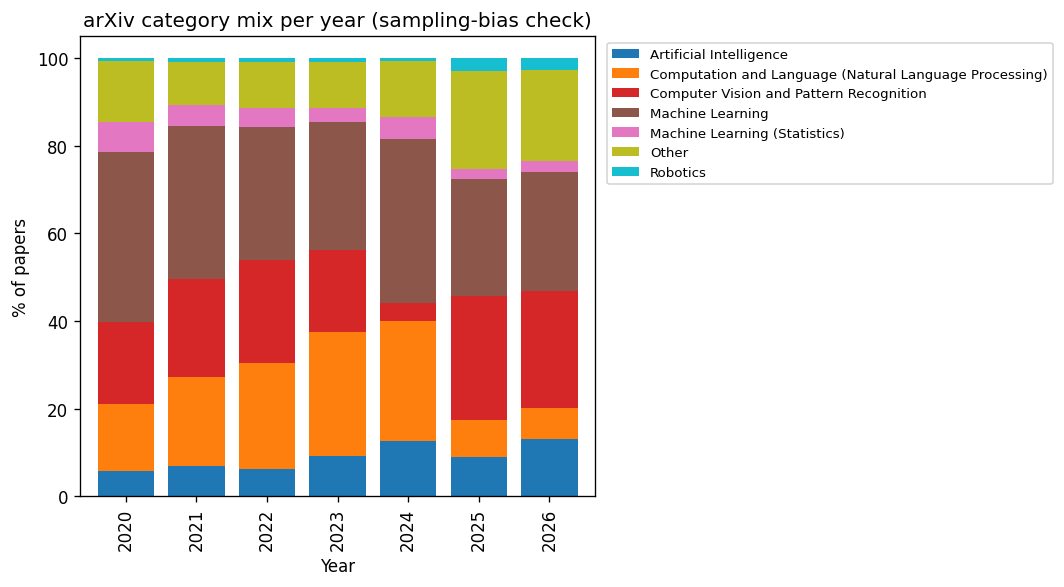

In [22]:
# 6.2 Sampling-bias check: category mix per year
top6 = df["category"].value_counts().head(6).index
cat_mix = pd.crosstab(df["category"].where(df["category"].isin(top6), "Other"),
                      df["year"], normalize="columns") * 100
print(cat_mix.round(1).to_string())

ax = cat_mix.T.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="tab10", width=0.8)
ax.set(title="arXiv category mix per year (sampling-bias check)", xlabel="Year", ylabel="% of papers")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
savefig("fig_category_mix_by_year")

                                              share_2020_22  share_2025_26  change_pp  growth_factor
topic                                                                                               
NLP, translation & speech                             14.84           1.80     -13.04           0.12
Deep neural network architectures (broad)             11.54           3.68      -7.86           0.32
Representation & supervised learning (broad)          11.16           7.35      -3.81           0.66
Evolutionary & combinatorial optimization              5.71           2.20      -3.51           0.39
Learning theory & statistical ML (broad)               9.83           6.38      -3.45           0.65
Applied machine learning (broad)                       7.75           4.31      -3.44           0.56
Graph neural networks                                  5.55           2.67      -2.88           0.48
Object & anomaly detection                             4.89           3.55      -1.34      

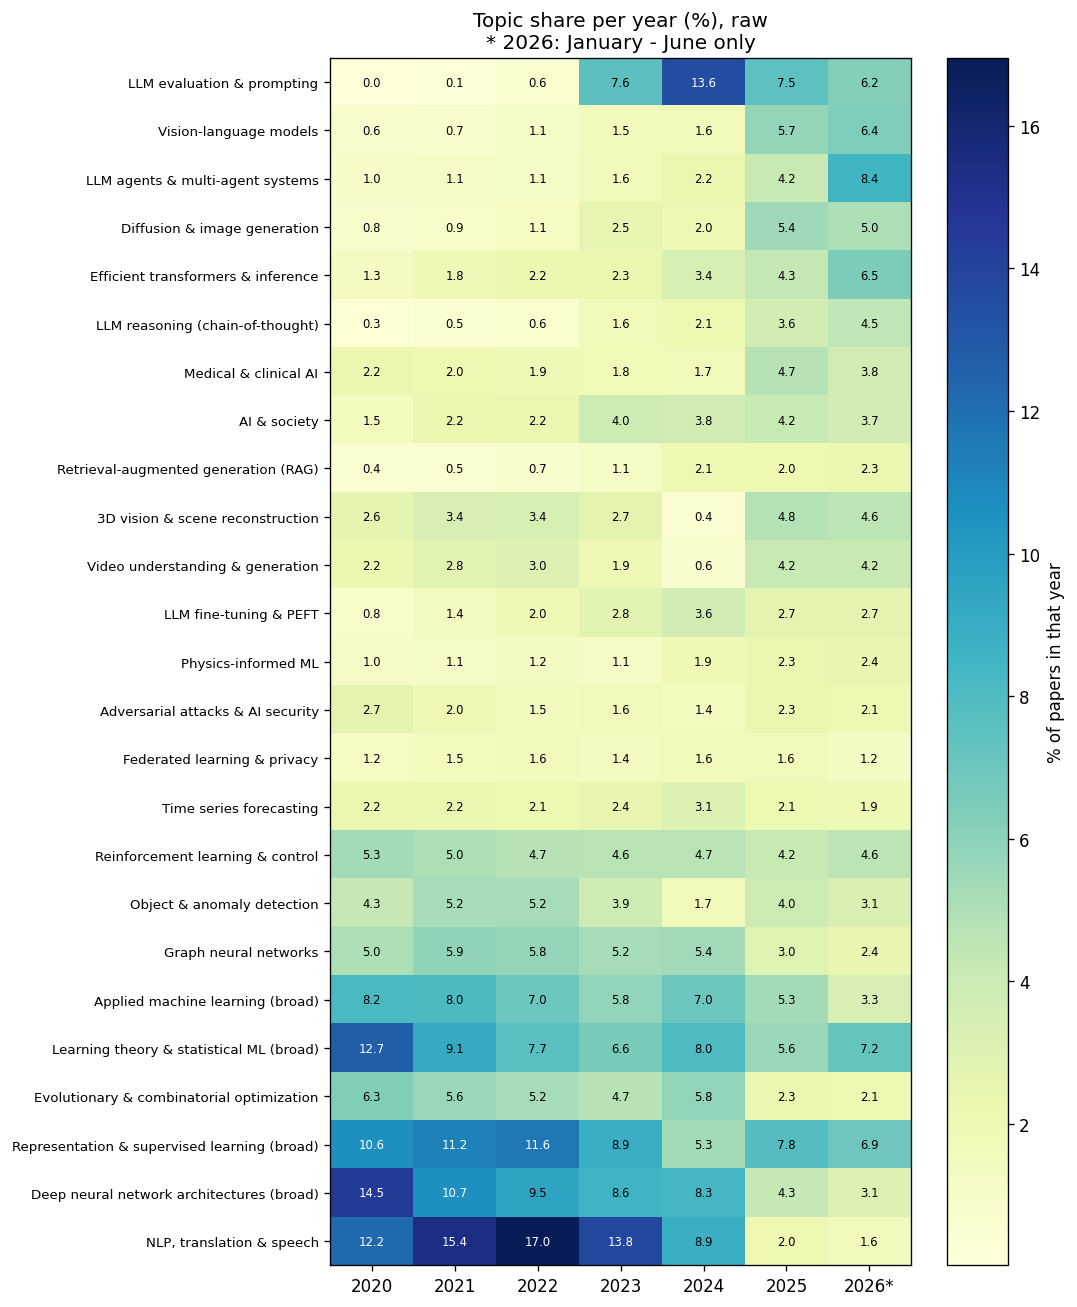

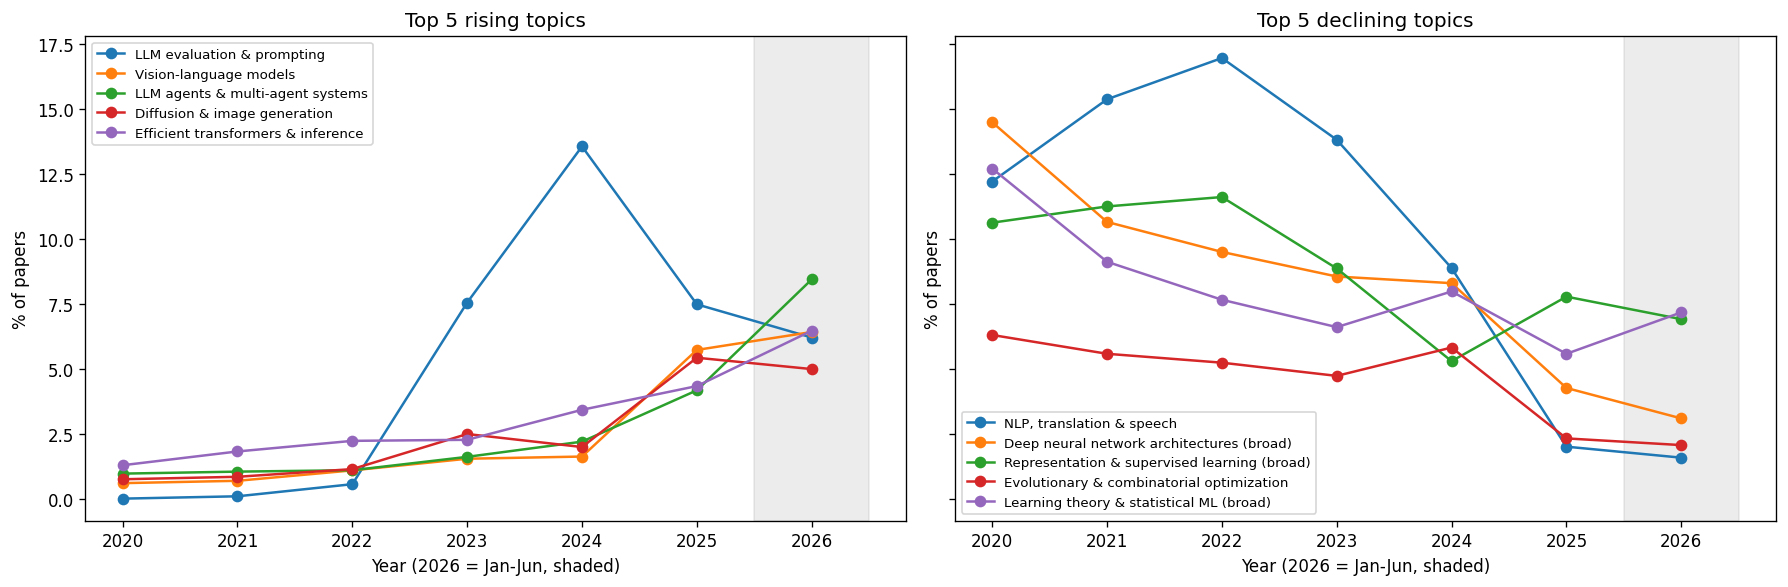

In [23]:
# 6.3 Raw trends: topic share per year, early (2020-22) vs recent (2025-26) period
def trend_table(share):
    early, recent = share[[2020, 2021, 2022]].mean(axis=1), share[[2025, 2026]].mean(axis=1)
    return pd.DataFrame({"share_2020_22": early, "share_2025_26": recent,
                         "change_pp": recent - early, "growth_factor": recent / early}).sort_values("change_pp")

def heatmap(share, order, title, name):
    hm = share.loc[order]
    fig, ax = plt.subplots(figsize=(9, 11))
    im = ax.imshow(hm.values, cmap="YlGnBu", aspect="auto")
    ax.set_xticks(range(hm.shape[1]), [f"{y}*" if y == 2026 else str(y) for y in hm.columns])
    ax.set_yticks(range(hm.shape[0]), hm.index, fontsize=8)
    for i in range(hm.shape[0]):
        for j in range(hm.shape[1]):
            v = hm.values[i, j]
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7,
                    color="white" if v > hm.values.max() * 0.6 else "black")
    plt.colorbar(im, ax=ax, label="% of papers in that year")
    ax.set_title(title + "\n* 2026: January - June only")
    savefig(name)

counts = pd.crosstab(df["topic"], df["year"])
share_year = counts / counts.sum(axis=0) * 100
share_year.round(2).to_csv(f"{OUT_DIR}/topic_share_by_year.csv")
trends = trend_table(share_year)
trends.round(3).to_csv(f"{OUT_DIR}/topic_trends.csv")
print(trends.round(2).to_string())

heatmap(share_year, trends.index[::-1], "Topic share per year (%), raw", "fig_topic_heatmap")

rising, declining = trends.index[::-1][:5], trends.index[:5]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, topics, title in zip(axes, [rising, declining], ["Top 5 rising topics", "Top 5 declining topics"]):
    for t in topics:
        ax.plot(share_year.columns, share_year.loc[t], marker="o", label=t)
    ax.axvspan(2025.5, 2026.5, color="grey", alpha=0.15)
    ax.set(title=title, xlabel="Year (2026 = Jan-Jun, shaded)", ylabel="% of papers")
    ax.legend(fontsize=8)
savefig("fig_rising_declining")

NMI (clusters vs categories): 0.24
ARI (clusters vs categories): 0.087

Top 3 arXiv categories per topic:
  3D vision & scene reconstruction               Computer Vision and Pattern Re 83% | Robotics 8% | Graphics 4%
  AI & society                                   Artificial Intelligence 32% | Computers and Society 17% | Human-Computer Interaction 13%
  Adversarial attacks & AI security              Machine Learning 30% | Cryptography and Security 30% | Computer Vision and Pattern Re 21%
  Applied machine learning (broad)               Machine Learning 53% | Artificial Intelligence 7% | Machine Learning (Statistics) 6%
  Deep neural network architectures (broad)      Machine Learning 49% | Computer Vision and Pattern Re 13% | Neural and Evolutionary Comput 11%
  Diffusion & image generation                   Computer Vision and Pattern Re 55% | Machine Learning 24% | Image and Video Processing 3%
  Efficient transformers & inference             Machine Learning 44% | Computer Vision 

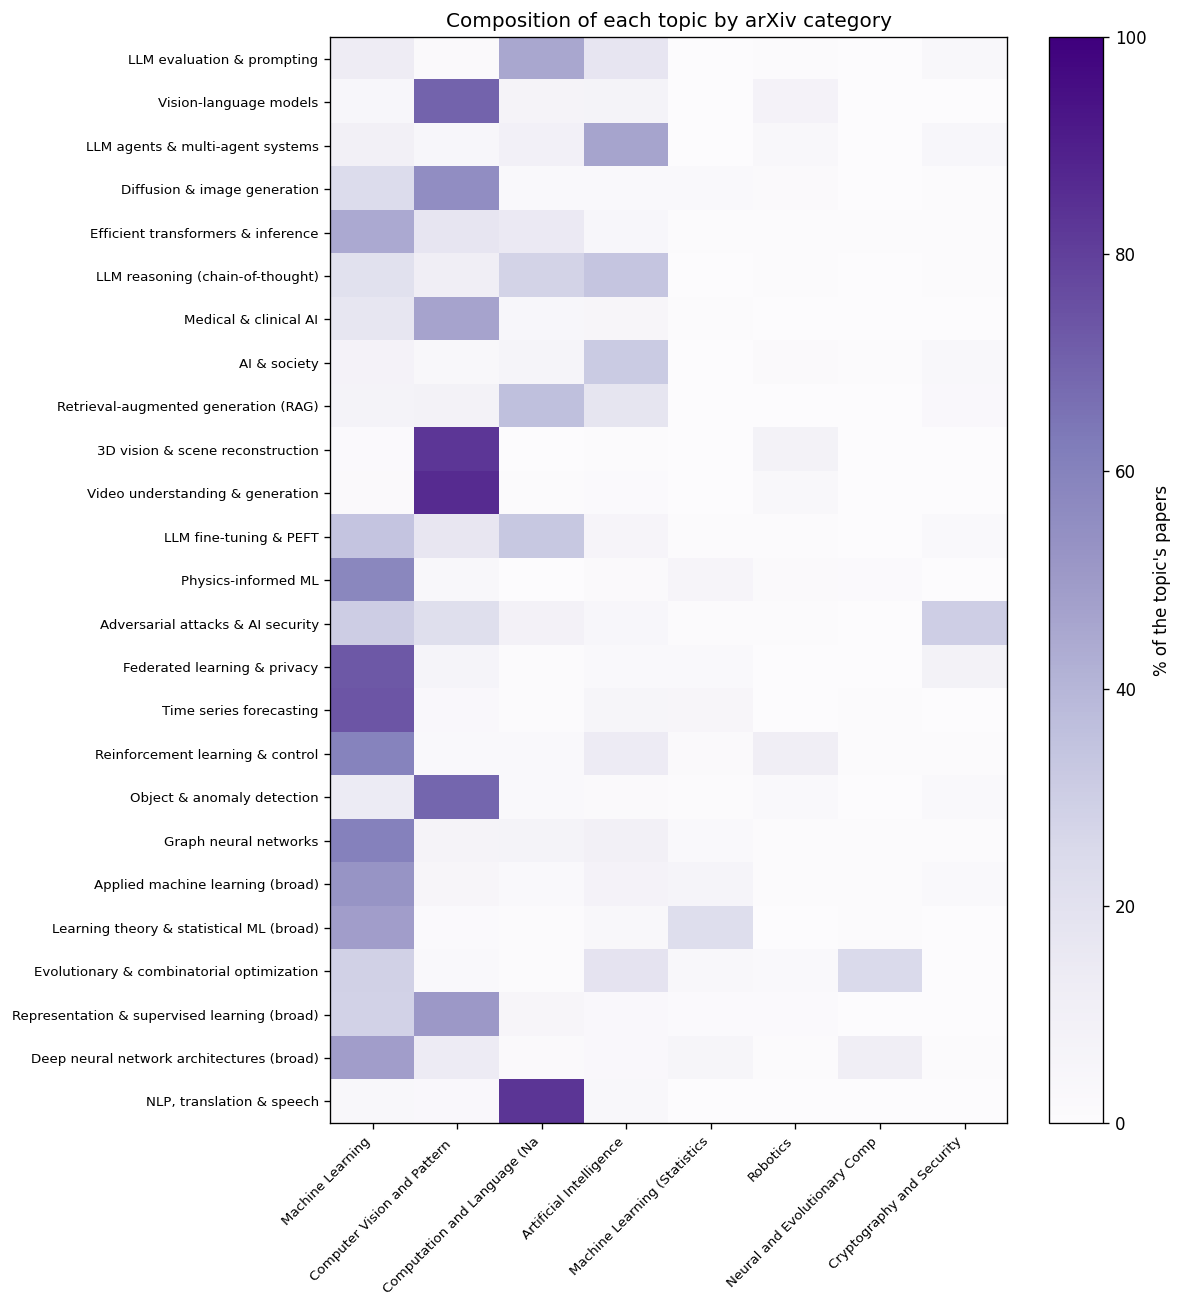

In [24]:
# 6.4 Clusters vs arXiv categories
print("NMI (clusters vs categories):", round(normalized_mutual_info_score(df["category"], df["cluster"]), 3))
print("ARI (clusters vs categories):", round(adjusted_rand_score(df["category"], df["cluster"]), 3))

ct_topic = pd.crosstab(df["topic"], df["category"], normalize="index") * 100
print("\nTop 3 arXiv categories per topic:")
for t in ct_topic.index:
    top3 = ct_topic.loc[t].nlargest(3)
    print(f"  {t:<46} " + " | ".join(f"{c[:30]} {v:.0f}%" for c, v in top3.items()))

ct_cat = pd.crosstab(df["category"], df["topic"], normalize="index")
print("\nNumber of topics needed to cover 80 % of a category's papers:")
for c in df["category"].value_counts().head(8).index:
    cum = ct_cat.loc[c].sort_values(ascending=False).cumsum()
    print(f"  {c:<55} {(cum < 0.8).sum() + 1}")

top8 = df["category"].value_counts().head(8).index
comp_cat = ct_topic[top8].loc[trends.index[::-1]]
fig, ax = plt.subplots(figsize=(10, 11))
im = ax.imshow(comp_cat.values, cmap="Purples", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(top8)), [c[:28] for c in top8], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(comp_cat)), comp_cat.index, fontsize=8)
plt.colorbar(im, ax=ax, label="% of the topic's papers")
ax.set_title("Composition of each topic by arXiv category")
savefig("fig_topic_vs_category")

## 7. Correcting the Sampling Bias (Post-Stratification)
Each paper is weighted so that every year has the category mix of the stable reference period 2020–2023
(weights capped at 5). Trends that keep their direction in both the raw and the adjusted version are considered robust.

In [25]:
# 7.1 Weights
TOP8 = df["category"].value_counts().head(8).index
df["cat_grp"] = df["category"].where(df["category"].isin(TOP8), "Other")
ref_mix = df[df["year"].between(2020, 2023)]["cat_grp"].value_counts(normalize=True)
obs_mix = pd.crosstab(df["year"], df["cat_grp"], normalize="index")
df["w"] = [ref_mix[c] / obs_mix.at[y, c] for y, c in zip(df["year"], df["cat_grp"])]
df["w"] = df["w"].clip(upper=5)

print(df.groupby("year")["w"].agg(["min", "median", "max"]).round(2).to_string())
wmix = df.pivot_table(index="cat_grp", columns="year", values="w", aggfunc="sum")
print((wmix / wmix.sum() * 100).round(1).to_string())       # should be ~constant per row

       min  median   max
year                    
2020  0.71    0.86  1.43
2021  0.89    0.96  1.29
2022  0.85    0.91  1.20
2023  0.76    1.12  1.43
2024  0.56    0.89  5.00
2025  0.24    0.73  4.38
2026  0.20    0.78  4.36
year                                                    2020  2021  2022  2023  2024  2025  2026
cat_grp                                                                                         
Artificial Intelligence                                  7.0   7.0   7.0   7.0   7.1   7.0   7.0
Computation and Language (Natural Language Processing)  21.9  21.9  21.9  21.9  22.1  21.9  21.9
Computer Vision and Pattern Recognition                 20.8  20.8  20.8  20.8  20.0  20.8  20.8
Cryptography and Security                                0.5   0.5   0.5   0.5   0.6   0.5   0.5
Machine Learning                                        33.3  33.3  33.3  33.3  33.7  33.3  33.3
Machine Learning (Statistics)                            4.8   4.8   4.8   4.8   4.9   4.8   4.8

                                              change_raw  change_adjusted  growth_factor_adjusted  robust
topic                                                                                                    
NLP, translation & speech                         -13.04           -12.97                    0.20    True
Deep neural network architectures (broad)          -7.86            -6.75                    0.40    True
Representation & supervised learning (broad)       -3.81            -4.52                    0.59    True
Applied machine learning (broad)                   -3.44            -3.54                    0.53    True
Evolutionary & combinatorial optimization          -3.51            -2.76                    0.52    True
Graph neural networks                              -2.88            -2.73                    0.51    True
Learning theory & statistical ML (broad)           -3.45            -2.02                    0.78    True
Object & anomaly detection                    

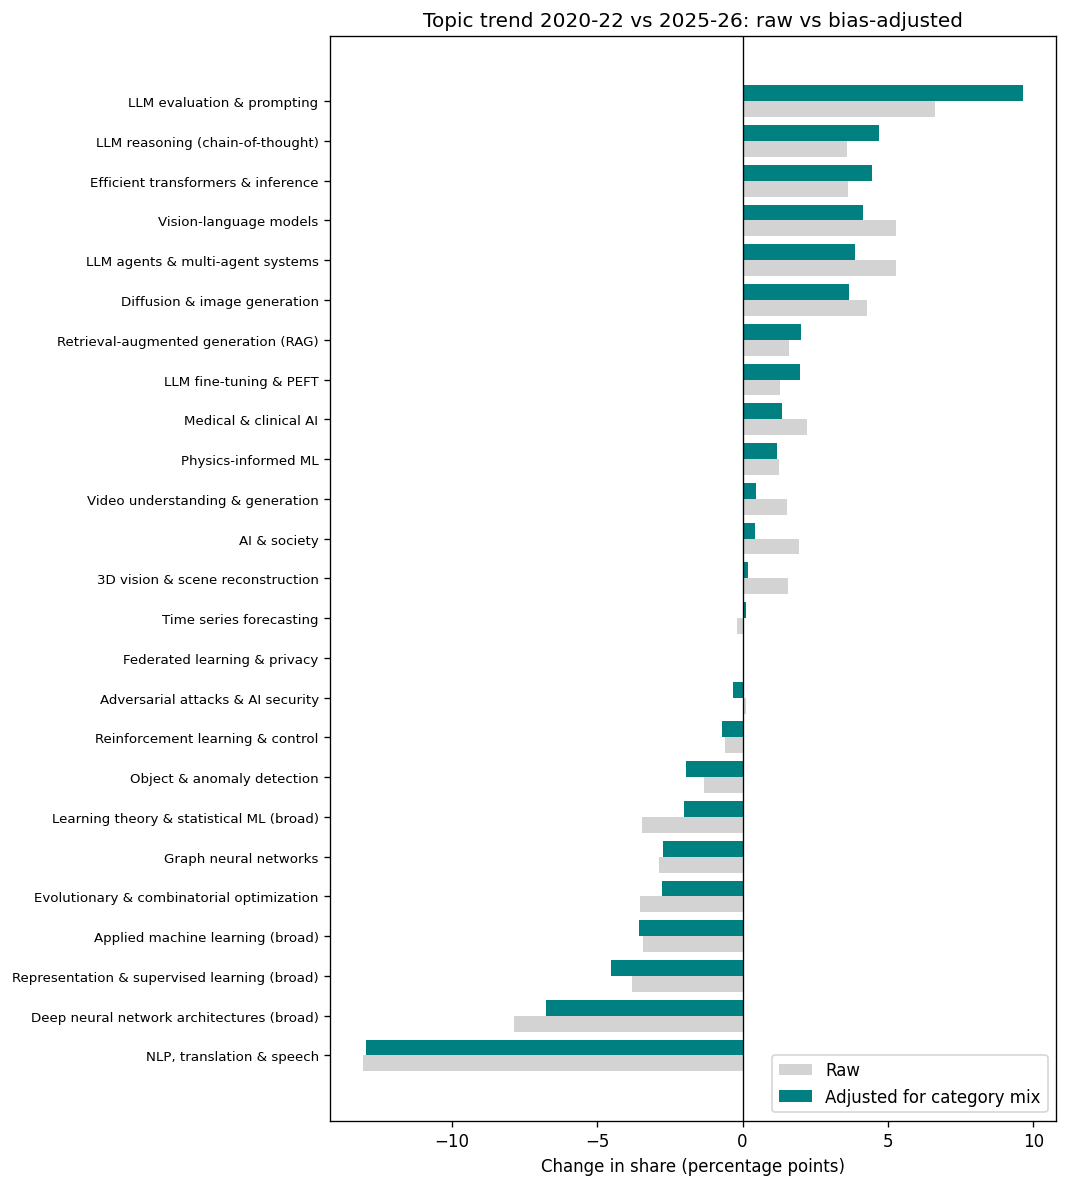

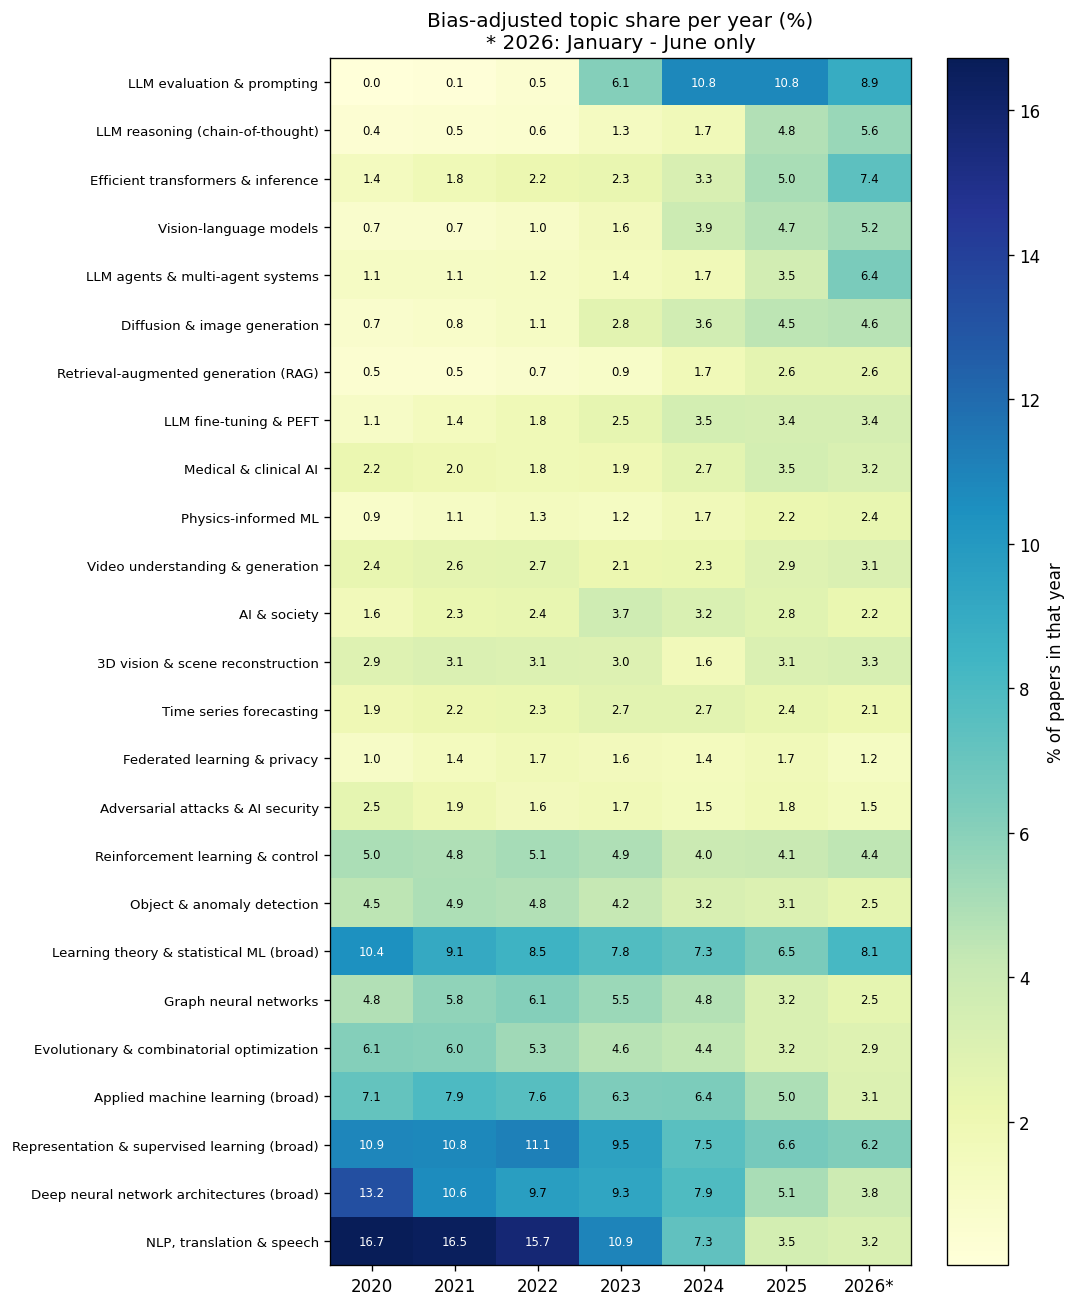

In [26]:
# 7.2 Adjusted shares and comparison with raw trends
w_counts = df.pivot_table(index="topic", columns="year", values="w", aggfunc="sum", fill_value=0)
share_adj = w_counts / w_counts.sum(axis=0) * 100
share_adj.round(2).to_csv(f"{OUT_DIR}/topic_share_by_year_adjusted.csv")

trends_adj = trend_table(share_adj)
comp = pd.DataFrame({"change_raw": trends["change_pp"], "change_adjusted": trends_adj["change_pp"],
                     "growth_factor_adjusted": trends_adj["growth_factor"]}).sort_values("change_adjusted")
comp["robust"] = np.sign(comp["change_raw"]) == np.sign(comp["change_adjusted"])
comp.round(3).to_csv(f"{OUT_DIR}/topic_trends_raw_vs_adjusted.csv")
print(comp.round(2).to_string())

y = np.arange(len(comp))
fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(y - 0.2, comp["change_raw"], height=0.4, color="lightgrey", label="Raw")
ax.barh(y + 0.2, comp["change_adjusted"], height=0.4, color="teal", label="Adjusted for category mix")
ax.set_yticks(y, comp.index, fontsize=8)
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Topic trend 2020-22 vs 2025-26: raw vs bias-adjusted", xlabel="Change in share (percentage points)")
ax.legend(loc="lower right")
savefig("fig_trends_raw_vs_adjusted")

heatmap(share_adj, comp.index[::-1], "Bias-adjusted topic share per year (%)", "fig_topic_heatmap_adjusted")

In [27]:
# 7.3 Headline number: combined share of LLM-related topics (bias-adjusted)
llm_topics = ["LLM evaluation & prompting", "LLM reasoning (chain-of-thought)",
              "Efficient transformers & inference", "LLM agents & multi-agent systems",
              "Retrieval-augmented generation (RAG)", "LLM fine-tuning & PEFT"]
llm = share_adj.loc[llm_topics].sum()
print(llm.round(1).to_string())
print(f"2020-22: {llm[[2020, 2021, 2022]].mean():.1f} % | 2025-26: {llm[[2025, 2026]].mean():.1f} %")

year
2020     4.4
2021     5.4
2022     7.0
2023    14.5
2024    22.7
2025    30.3
2026    34.4
2020-22: 5.6 % | 2025-26: 32.3 %


## 8. Summary
- 227,389 arXiv papers (2020 – June 2026) were grouped into 25 research topics with TF-IDF, Truncated SVD and K-Means.
- k = 25 was chosen from internal validity indices, manual inspection and a stability check against k = 20.
- The dataset shows strong sampling artefacts (e.g. Computer Vision in 2024, NLP in 2025); trends were therefore also computed with post-stratification weights.
- Robust finding: research is shifting from designing neural architectures and classic NLP towards work built around large foundation models (LLM evaluation, reasoning, agents, efficiency, RAG, fine-tuning), multimodal and generative models.